## Trend Study

I need to figure out a seisible take off weight, wing aspect ratio, thrust and more. The best starting point is to perform a trend study using available data.

The below code was generate by chatgpt and fact checked by myself.

#### Dataset:

In [26]:
# ============================================================
# Fixed-wing UAV / drone trend study dataset and plots
# ============================================================
#
# Trends:
# 1) Thrust-equivalent vs MTOW
# 2) MTOW vs wing loading
# 3) MTOW vs range
# 4) Wing loading vs aspect ratio
# 5) Endurance vs battery size
#
# Dataset rules:
# - Fixed-wing or fixed-wing VTOL only.
# - Multirotor-only aircraft are excluded.
# - Battery drones are kept wherever possible.
# - Missing data is left as NaN rather than guessed silently.
#
# Important:
# - "thrust_equiv_N" is not always measured thrust.
# - For propeller aircraft, it is estimated from:
#
#       T = eta_prop * P / V
#
#   where P may be:
#   - published shaft/electric power, or
#   - estimated average electrical power from battery_Wh/endurance_h.
#
# - For fuel aircraft, battery_Wh is left as NaN unless a hybrid battery pack is stated.
# - For battery entries where only cell count + Ah are known, Wh is estimated using:
#
#       Wh = cells * nominal_cell_voltage * Ah
#
# - For Li-ion/LiPo, nominal_cell_voltage = 3.7 V by default.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Constants
# -----------------------------
g = 9.80665

KT_TO_MS = 0.514444
MPH_TO_MS = 0.44704
KMH_TO_MS = 1 / 3.6
HP_TO_W = 745.7
LBF_TO_N = 4.44822
LB_TO_KG = 0.45359237
FT_TO_M = 0.3048
IN_TO_M = 0.0254
SQIN_TO_M2 = 0.00064516
DM2_TO_M2 = 0.01
NMI_TO_KM = 1.852
MI_TO_KM = 1.609344

NOMINAL_LI_CELL_VOLTAGE = 3.7
eta_prop = 0.70


# -----------------------------
# Helper functions
# -----------------------------
def battery_wh_from_cells(cells, ah, nominal_cell_voltage=NOMINAL_LI_CELL_VOLTAGE, packs_in_series=1, packs_in_parallel=1):
    """
    Estimate battery energy in Wh from cell count and Ah.
    Assumes cells are in series within each pack unless otherwise stated.
    """
    if pd.isna(cells) or pd.isna(ah):
        return np.nan
    return cells * nominal_cell_voltage * ah * packs_in_series * packs_in_parallel


def battery_wh_from_voltage(voltage, ah, packs_in_parallel=1):
    if pd.isna(voltage) or pd.isna(ah):
        return np.nan
    return voltage * ah * packs_in_parallel


def add_aircraft(
    aircraft,
    sector,
    application,
    configuration,
    power_source,
    fuel_or_energy_type,
    mtow_kg,
    wingspan_m=np.nan,
    wing_area_m2=np.nan,
    wing_loading_kg_m2=np.nan,
    endurance_h=np.nan,
    range_km=np.nan,
    range_type="not stated",
    cruise_speed_ms=np.nan,
    max_speed_ms=np.nan,
    published_thrust_N=np.nan,
    power_W=np.nan,
    battery_Wh=np.nan,
    battery_Ah=np.nan,
    battery_voltage_V=np.nan,
    battery_cells=np.nan,
    battery_packs_parallel=1,
    battery_size_note="not stated",
    source="",
    source_url="",
    data_quality_note=""
):
    return {
        "aircraft": aircraft,
        "sector": sector,
        "application": application,
        "configuration": configuration,
        "power_source": power_source,
        "fuel_or_energy_type": fuel_or_energy_type,

        "mtow_kg": mtow_kg,
        "wingspan_m": wingspan_m,
        "wing_area_m2": wing_area_m2,
        "wing_loading_kg_m2_given": wing_loading_kg_m2,

        "endurance_h": endurance_h,
        "range_km": range_km,
        "range_type": range_type,

        "cruise_speed_ms": cruise_speed_ms,
        "max_speed_ms": max_speed_ms,

        "published_thrust_N": published_thrust_N,
        "power_W": power_W,

        "battery_Wh": battery_Wh,
        "battery_Ah": battery_Ah,
        "battery_voltage_V": battery_voltage_V,
        "battery_cells": battery_cells,
        "battery_packs_parallel": battery_packs_parallel,
        "battery_size_note": battery_size_note,

        "source": source,
        "source_url": source_url,
        "data_quality_note": data_quality_note,
    }


# -----------------------------
# Dataset
# -----------------------------
data = [

    # ========================================================
    # Larger fuel / hybrid / military / tactical fixed-wing UAVs
    # ========================================================

    add_aircraft(
        aircraft="RQ-4 Global Hawk",
        sector="military",
        application="HALE ISR",
        configuration="fixed-wing turbofan",
        power_source="fossil fuel",
        fuel_or_energy_type="jet fuel",
        mtow_kg=14628,
        wingspan_m=39.8,
        wing_area_m2=50.10,
        endurance_h=34,
        range_km=12300 * NMI_TO_KM,
        range_type="published range, nautical miles converted",
        cruise_speed_ms=310 * KT_TO_MS,
        published_thrust_N=7600 * LBF_TO_N,
        source="USAF fact sheet for main specs; public geometry source for wing area",
        source_url="https://www.af.mil/About-Us/Fact-Sheets/Display/Article/104516/rq-4-global-hawk/ ; https://aircraft.fandom.com/wiki/Northrop_Grumman_RQ-4_Global_Hawk",
    ),

    add_aircraft(
        aircraft="MQ-9 Reaper",
        sector="military",
        application="MALE ISR / strike",
        configuration="fixed-wing turboprop",
        power_source="fossil fuel",
        fuel_or_energy_type="aviation fuel",
        mtow_kg=4760,
        wingspan_m=20.1,
        endurance_h=27,
        range_km=1150 * MI_TO_KM,
        range_type="published range, miles converted",
        cruise_speed_ms=150 * KT_TO_MS,
        power_W=900 * HP_TO_W,
        source="USAF MQ-9 Reaper fact sheet",
        source_url="https://www.af.mil/About-Us/Fact-Sheets/Display/Article/104470/mq-9-reaper/",
    ),

    add_aircraft(
        aircraft="MQ-1 Predator",
        sector="military",
        application="MALE ISR / strike",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="petrol/gasoline aviation piston fuel",
        mtow_kg=1020,
        wingspan_m=14.8,
        wing_area_m2=11.45,
        endurance_h=24,
        range_km=1250,
        range_type="published range",
        cruise_speed_ms=70 * KT_TO_MS,
        power_W=86_000,
        source="Public MQ-1 Predator specifications",
        source_url="https://en.wikipedia.org/wiki/General_Atomics_MQ-1_Predator",
    ),

    add_aircraft(
        aircraft="Bayraktar TB2",
        sector="military",
        application="MALE tactical ISR / strike",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="petrol/gasoline piston engine",
        mtow_kg=700,
        wingspan_m=12.0,
        endurance_h=27,
        range_km=300,
        range_type="line-of-sight communications/control range",
        cruise_speed_ms=70 * KT_TO_MS,
        power_W=100 * HP_TO_W,
        source="Baykar TB2 technical specifications",
        source_url="https://baykartech.com/en/uav/bayraktar-tb2/",
    ),

    add_aircraft(
        aircraft="ScanEagle",
        sector="military / civil",
        application="small tactical ISR / maritime surveillance",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="heavy fuel / petrol depending on variant",
        mtow_kg=28.0,
        wingspan_m=3.1,
        endurance_h=20,
        cruise_speed_ms=55 * MPH_TO_MS,
        power_W=1.5 * HP_TO_W,
        source="USAF ScanEagle fact sheet / Insitu product data",
        source_url="https://www.af.mil/About-Us/Fact-Sheets/Display/Article/104532/scan-eagle/ ; https://www.insitu.com/products/scaneagle",
    ),

    add_aircraft(
        aircraft="Insitu Integrator",
        sector="military / civil",
        application="tactical ISR / payload integration",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="heavy fuel",
        mtow_kg=79.0,
        wingspan_m=4.9,
        endurance_h=24,
        cruise_speed_ms=46.0,
        source="Insitu Integrator specifications",
        source_url="https://www.insitu.com/products/integrator",
    ),

    add_aircraft(
        aircraft="Aerosonde Mk 4.7 FW",
        sector="military / civil",
        application="ISR / maritime / multi-payload",
        configuration="fixed-wing heavy-fuel piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="heavy fuel",
        mtow_kg=42.2,
        wingspan_m=4.4,
        endurance_h=14,
        range_km=140,
        range_type="published range",
        cruise_speed_ms=42 * KT_TO_MS,
        source="Aerosonde Mk 4.7 public product listing",
        source_url="https://www.unmannedsystemstechnology.com/company/textron-systems/aerosonde-mk-4-7-fixed-wing-uas/",
    ),

    add_aircraft(
        aircraft="Penguin Mk2X",
        sector="military / civil",
        application="long-endurance surveillance",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="petrol/gasoline piston engine",
        mtow_kg=25.0,
        wingspan_m=3.3,
        endurance_h=20,
        range_km=180,
        range_type="communications range",
        cruise_speed_ms=40 * KT_TO_MS,
        source="Redwire Penguin Mk2X product archive",
        source_url="https://rdw.com/product-archive/uncrewed-systems/penguin-mk2x/",
    ),

    add_aircraft(
        aircraft="R3600 ICE",
        sector="civil / public-service",
        application="BVLOS mapping / inspection / emergency service",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="internal combustion engine fuel",
        mtow_kg=28.0,
        wingspan_m=3.6,
        wing_area_m2=1.33,
        endurance_h=7,
        range_km=500,
        range_type="published range",
        cruise_speed_ms=85 / 3.6,
        power_W=5.1e3,
        source="MB+Partner R3600 specifications",
        source_url="https://mbptech.de/en/drones/",
    ),

    add_aircraft(
        aircraft="Mugin 3600 VTOL",
        sector="civil / military-used platform",
        application="large-area mapping / ISR / payload platform",
        configuration="fixed-wing hybrid VTOL",
        power_source="hybrid",
        fuel_or_energy_type="petrol/gasoline forward propulsion + battery VTOL system",
        mtow_kg=40,
        wingspan_m=3.6,
        wing_area_m2=132 * DM2_TO_M2,
        endurance_h=3,
        range_type="restricted to flight time in source",
        cruise_speed_ms=120 * KMH_TO_MS,
        source="Mugin 3600 product/specification listing",
        source_url="https://fpvmodel.com/products/mugin-3-3600mm-h-tail-carbon-fiber-vtol-uav",
    ),

    add_aircraft(
        aircraft="Mugin 4450 VTOL",
        sector="civil / military-used platform",
        application="heavy payload VTOL fixed-wing platform",
        configuration="fixed-wing hybrid VTOL",
        power_source="hybrid",
        fuel_or_energy_type="petrol/gasoline forward propulsion + battery VTOL system",
        mtow_kg=85,
        wingspan_m=4.51,
        wing_area_m2=236 * DM2_TO_M2,
        endurance_h=np.nan,
        source="Mugin 4450 public platform specification",
        source_url="https://www.rcgroups.com/forums/showthread.php?3359493-85kg-Take-off-Weight-Super-Huge-Mugin-4450-VTOL=",
        data_quality_note="Forum/product-style source; verify before final academic use.",
    ),

    add_aircraft(
        aircraft="Mugin 5000 VTOL",
        sector="civil / military-used platform",
        application="heavy payload long-endurance VTOL platform",
        configuration="fixed-wing hybrid VTOL",
        power_source="hybrid",
        fuel_or_energy_type="petrol/gasoline forward propulsion + battery VTOL system",
        mtow_kg=90,
        wingspan_m=5.0,
        wing_area_m2=261.5 * DM2_TO_M2,
        endurance_h=7,
        range_type="source gives 6 to 8 h; midpoint used",
        cruise_speed_ms=120 * KMH_TO_MS,
        source="Mugin 5000 platform listing",
        source_url="https://fpvmodel.com/products/mugin-5000mm-super-large-vtol-uav-platform",
    ),

    add_aircraft(
        aircraft="RQ-7B Shadow",
        sector="military",
        application="tactical ISR",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="aviation gasoline/heavy fuel depending on variant",
        mtow_kg=204,
        wingspan_m=6.1,
        endurance_h=9,
        range_km=125,
        range_type="operational range",
        cruise_speed_ms=np.nan,
        source="Public RQ-7 Shadow specifications",
        source_url="https://en.wikipedia.org/wiki/AAI_RQ-7_Shadow",
    ),

    add_aircraft(
        aircraft="Elbit Hermes 450",
        sector="military",
        application="MALE ISR",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="rotary/piston engine fuel",
        mtow_kg=550,
        wingspan_m=10.5,
        endurance_h=17,
        range_km=300,
        range_type="communications/mission radius figure, depending on source",
        cruise_speed_ms=70 * KT_TO_MS,
        source="Public Hermes 450 specifications",
        source_url="https://en.wikipedia.org/wiki/Elbit_Hermes_450",
    ),

    add_aircraft(
        aircraft="IAI Heron",
        sector="military",
        application="MALE ISR",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="aviation fuel",
        mtow_kg=1150,
        wingspan_m=16.6,
        endurance_h=45,
        range_km=350,
        range_type="line-of-sight / control range figure in many public summaries",
        cruise_speed_ms=np.nan,
        source="Public IAI Heron specifications",
        source_url="https://en.wikipedia.org/wiki/IAI_Heron",
    ),

    add_aircraft(
        aircraft="WK450 Watchkeeper",
        sector="military",
        application="tactical ISR",
        configuration="fixed-wing rotary/piston engine",
        power_source="fossil fuel",
        fuel_or_energy_type="aviation fuel",
        mtow_kg=485,
        wingspan_m=10.9,
        endurance_h=17,
        range_km=200,
        range_type="operational range/control range figure",
        source="Public Watchkeeper WK450 specifications",
        source_url="https://en.wikipedia.org/wiki/Thales_Watchkeeper_WK450",
    ),

    add_aircraft(
        aircraft="Orion UAS",
        sector="military / civil",
        application="long-endurance ISR",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="heavy fuel / gasoline class",
        mtow_kg=115,
        wingspan_m=5.0,
        endurance_h=24,
        source="Public Orion UAS specifications",
        source_url="https://www.unmannedsystemstechnology.com/company/eos-technologie/orion-uas/",
    ),

    add_aircraft(
        aircraft="Penguin C",
        sector="civil / military-used",
        application="ISR / surveillance / payload integration",
        configuration="fixed-wing piston-prop",
        power_source="fossil fuel",
        fuel_or_energy_type="petrol/gasoline piston engine",
        mtow_kg=21.5,
        wingspan_m=3.3,
        endurance_h=20,
        cruise_speed_ms=22,
        source="Public Penguin C specifications",
        source_url="https://www.unmannedsystemstechnology.com/company/uav-factory/penguin-c/",
    ),

    add_aircraft(
        aircraft="Quantum-Systems Reliant",
        sector="military / government",
        application="Group 2 VTOL ISR",
        configuration="fixed-wing VTOL internal combustion",
        power_source="fossil fuel",
        fuel_or_energy_type="heavy fuel-compatible internal combustion engine",
        mtow_kg=np.nan,
        endurance_h=10,
        source="Quantum-Systems Reliant page",
        source_url="https://quantum-systems.com/reliant/",
        data_quality_note="MTOW not stated in retrieved source snippet.",
    ),

    # ========================================================
    # Battery-electric / electric fixed-wing and VTOL UAVs
    # ========================================================

    add_aircraft(
        aircraft="eBee X",
        sector="civil",
        application="mapping / surveying",
        configuration="fixed-wing electric-prop",
        power_source="battery",
        fuel_or_energy_type="rechargeable battery",
        mtow_kg=1.6,
        wingspan_m=1.16,
        endurance_h=1.5,
        range_km=8,
        range_type="radio link range, up to figure",
        cruise_speed_ms=75 * KMH_TO_MS,
        source="senseFly / AgEagle eBee X specifications",
        source_url="https://www.sensefly.com/drones/ebee-x/ ; https://pdf.aeroexpo.online/pdf/sensefly/ebee-x/175240-27506.html",
    ),

    add_aircraft(
        aircraft="senseFly eBee Classic",
        sector="civil",
        application="mapping / surveying",
        configuration="fixed-wing electric-prop",
        power_source="battery",
        fuel_or_energy_type="rechargeable battery",
        mtow_kg=0.69,
        wingspan_m=0.96,
        endurance_h=0.75,
        range_km=3,
        range_type="radio link range",
        source="senseFly eBee technical specification PDF",
        source_url="https://hkd-geomatique.com/images/04_Technologies/fiches-materiels/SenseFly-Ebee.pdf",
    ),

    add_aircraft(
        aircraft="WingtraOne GEN II",
        sector="civil",
        application="surveying / mapping",
        configuration="fixed-wing tailsitter VTOL electric",
        power_source="battery",
        fuel_or_energy_type="two Li-ion smart batteries",
        mtow_kg=4.8,
        wingspan_m=1.25,
        endurance_h=59 / 60,
        range_km=10,
        range_type="telemetry range",
        battery_Wh=2 * 99,
        battery_Ah=7.5,
        battery_voltage_V=14.4,
        battery_size_note="two 99 Wh batteries required as a pair",
        source="WingtraOne GEN II technical specifications",
        source_url="https://www.korecgroup.com/product/wingtraone-gen-ii/ ; https://geotech.co.il/wp-content/uploads/2021/08/Wingtra-Technical-Specifications-gen-II.pdf",
    ),

    add_aircraft(
        aircraft="Quantum-Systems Trinity F90+",
        sector="civil",
        application="mapping / surveying",
        configuration="fixed-wing eVTOL",
        power_source="battery",
        fuel_or_energy_type="rechargeable battery",
        mtow_kg=5.0,
        wingspan_m=2.394,
        endurance_h=1.5,
        range_km=100,
        range_type="unlocked range figure; source also gives 70 km standard",
        cruise_speed_ms=61.2 * KMH_TO_MS,
        battery_Ah=12,
        battery_size_note="source gives 12,000 mAh pack capacity but voltage not stated in retrieved snippet",
        source="Trinity F90+ product/specification pages",
        source_url="https://bssholland.com/product/trinity-f90-evtol-fixed-wing-mapping-uas/ ; https://optron.com/quantum-systems/wp-content/uploads/2022/02/ds_quantum-trinity-f90.pdf",
    ),

    add_aircraft(
        aircraft="Quantum-Systems Trinity Pro",
        sector="civil / government",
        application="mapping / surveying",
        configuration="fixed-wing eVTOL",
        power_source="battery",
        fuel_or_energy_type="rechargeable battery",
        mtow_kg=5.75,
        wingspan_m=2.394,
        endurance_h=1.5,
        range_km=7.5,
        range_type="command and control range, upper figure",
        cruise_speed_ms=17,
        source="Quantum-Systems Trinity Pro technical data",
        source_url="https://quantum-systems.com/trinity-pro/",
    ),

    add_aircraft(
        aircraft="DeltaQuad Evo",
        sector="civil / government / defence",
        application="long-range mapping / ISR / security",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="semi-solid-state lithium-ion",
        mtow_kg=10.0,
        wingspan_m=2.69,
        wing_area_m2=84 * DM2_TO_M2,
        endurance_h=272 / 60,
        range_km=270,
        range_type="range through air",
        cruise_speed_ms=16.54,
        battery_Wh=battery_wh_from_cells(cells=6, ah=22, packs_in_parallel=2),
        battery_Ah=22,
        battery_cells=6,
        battery_packs_parallel=2,
        battery_size_note="dual-battery case; source gives 6 cells and 22 Ah per battery",
        source="DeltaQuad Evo technical specifications",
        source_url="https://www.deltaquad.com/resources/technical-specifications ; https://docs.deltaquad.com/evo/vehicle-specifications",
    ),

    add_aircraft(
        aircraft="DeltaQuad Pro",
        sector="civil / government",
        application="long-range mapping / surveillance",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="rechargeable battery",
        mtow_kg=10.0,
        wingspan_m=np.nan,
        endurance_h=2.0,
        range_km=150,
        range_type="auxiliary battery range figure",
        source="Heliguy DeltaQuad Pro article",
        source_url="https://www.heliguy.com/blogs/posts/heliguy-selling-deltaquad-pro-fixed-wing-drone/",
    ),

    add_aircraft(
        aircraft="Quantum-Systems Vector AI",
        sector="military / government",
        application="tactical ISR",
        configuration="fixed-wing eVTOL",
        power_source="battery",
        fuel_or_energy_type="rechargeable battery",
        mtow_kg=9.5,
        wingspan_m=2.8,
        endurance_h=3.0,
        source="Quantum-Systems Vector AI datasheet",
        source_url="https://quantum-systems.com/wp-content/uploads/2025/05/QS_VectorAI_A4_BS_3mm_250502_Screen.pdf",
    ),

    add_aircraft(
        aircraft="AeroVironment Puma 3 AE",
        sector="military / civil",
        application="hand-launched tactical ISR",
        configuration="fixed-wing electric-prop",
        power_source="battery",
        fuel_or_energy_type="rechargeable battery",
        mtow_kg=15 * LB_TO_KG,
        wingspan_m=9.2 * FT_TO_M,
        endurance_h=3.0,
        range_km=20,
        range_type="standard range; other source variants give 15 km / LRTA figures",
        source="AeroVironment Puma 3 AE product page / press release",
        source_url="https://www.avinc.com/solution/puma-3-ae/ ; https://investor.avinc.com/news-releases/news-release-details/aerovironment-receives-puma-3-ae-and-raven-unmanned-aircraft",
    ),

    add_aircraft(
        aircraft="RQ-11 Raven",
        sector="military",
        application="hand-launched low-altitude ISR",
        configuration="fixed-wing electric-prop",
        power_source="battery",
        fuel_or_energy_type="rechargeable battery",
        mtow_kg=4.2 * LB_TO_KG,
        wingspan_m=1.4,
        endurance_h=1.0,
        range_km=10,
        range_type="operational range",
        source="AeroVironment press release / public specs",
        source_url="https://investor.avinc.com/news-releases/news-release-details/aerovironment-receives-puma-3-ae-and-raven-unmanned-aircraft",
    ),

    add_aircraft(
        aircraft="YUAV Y37",
        sector="civil / government",
        application="long-endurance VTOL fixed-wing mapping / inspection",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=20.0,
        wingspan_m=3.7,
        endurance_h=8.5,
        range_km=614,
        range_type="validated maximum range claimed by source",
        cruise_speed_ms=72.5 * KMH_TO_MS,
        battery_Wh=2700,
        battery_voltage_V=48,
        battery_size_note="48 V, 2700 Wh battery",
        source="YUAV Y37 specification article",
        source_url="https://www.skyeyeuav.com/yuav-y37-a-new-standard-in-long-endurance-vtol-fixed-wing-uavs/",
    ),

    add_aircraft(
        aircraft="Airmobi V25",
        sector="civil / public safety",
        application="surveying / inspection / security",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=13.5,
        wingspan_m=2.5,
        endurance_h=3 + 40 / 60,
        source="Airmobi V-Series specifications",
        source_url="https://www.airmobi.com/airmobi-v-series-vtol-fixed-wing-uavs-comprehensive-overview-and-comparison/",
    ),

    add_aircraft(
        aircraft="Mugin EV350 VTOL",
        sector="civil / payload platform",
        application="electric VTOL mapping / inspection",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=22,
        wingspan_m=3.5,
        wing_area_m2=100 * DM2_TO_M2,
        endurance_h=3,
        range_km=180,
        range_type="published flight range",
        cruise_speed_ms=21,
        source="Mugin product catalogue",
        source_url="https://www.muginuav.com/wp-content/uploads/2020/04/Mugin-Product-Catalog-2020.pdf",
    ),

    add_aircraft(
        aircraft="Mugin 2930 Pro VTOL Electric",
        sector="civil / payload platform",
        application="electric VTOL mapping / payload platform",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=25,
        wingspan_m=2.93,
        wing_area_m2=90 * DM2_TO_M2,
        endurance_h=1.5,
        cruise_speed_ms=20,
        source="Mugin 2930 Pro public listing",
        source_url="https://seabee.no/mugin-2-pro-2930mm/",
    ),

    add_aircraft(
        aircraft="Foxtech AYK-250 VTOL",
        sector="civil / government",
        application="inspection / surveillance / mapping",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=15,
        wingspan_m=2.5,
        cruise_speed_ms=26,
        battery_size_note="12S working voltage stated; optional batteries listed separately",
        source="Foxtech AYK-250 VTOL specifications",
        source_url="https://www.foxtechfpv.com/foxtech-ayk-250-vtol.html",
    ),

    add_aircraft(
        aircraft="Foxtech Great Shark 330 VTOL",
        sector="civil / government",
        application="inspection / mapping / payload platform",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=24,
        wingspan_m=3.2,
        cruise_speed_ms=26,
        battery_Wh=battery_wh_from_cells(cells=6, ah=32, packs_in_parallel=2),
        battery_Ah=32,
        battery_cells=6,
        battery_packs_parallel=2,
        battery_size_note="option listed as 2x Diamond 6S 32000 mAh HV; Wh estimated from nominal cell voltage",
        source="Foxtech Great Shark 330 VTOL specifications",
        source_url="https://www.foxtechfpv.com/foxtech-great-shark-330-vtol.html",
    ),

    add_aircraft(
        aircraft="Foxtech Nimbus VTOL V2",
        sector="civil / hobby-professional",
        application="mapping / survey / FPV",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="LiPo battery",
        mtow_kg=6.0,
        wingspan_m=1.8,
        cruise_speed_ms=35,
        battery_Wh=battery_wh_from_cells(cells=6, ah=12),
        battery_Ah=12,
        battery_cells=6,
        battery_size_note="source gives 6S 10000-12000 mAh; upper value used",
        source="Foxtech Nimbus VTOL V2 manual",
        source_url="https://www.foxtechfpv.com/product/fixedwing/2008202-Nimbus-manual-en.pdf",
    ),

    add_aircraft(
        aircraft="Skywalker X8",
        sector="civil / hobby-professional",
        application="FPV / mapping / payload platform",
        configuration="fixed-wing electric flying wing",
        power_source="battery",
        fuel_or_energy_type="LiPo/Li-ion battery",
        mtow_kg=5.5,
        wingspan_m=2.12,
        wing_area_m2=80 * DM2_TO_M2,
        battery_Wh=battery_wh_from_cells(cells=6, ah=16),
        battery_Ah=16,
        battery_cells=6,
        battery_size_note="manual gives 6S 16000 mAh; Wh estimated from nominal cell voltage",
        source="Skywalker X8 specification/manual sources",
        source_url="https://www.uavmodel.com/products/skywalker-x8-2122mm-uav-fixed-wing ; https://myosuploads3.banggood.com/products/20240504/20240504031303X-8InstallationManual.pdf",
    ),

    add_aircraft(
        aircraft="Makeflyeasy Believer",
        sector="civil / hobby-professional",
        application="aerial survey / mapping",
        configuration="fixed-wing electric twin-boom",
        power_source="battery",
        fuel_or_energy_type="LiPo/Li-ion battery",
        mtow_kg=5.5,
        wingspan_m=1.96,
        wing_area_m2=51 * DM2_TO_M2,
        endurance_h=90 / (20 * 3.6),  # derived from 90 km range and 20 m/s recommended speed
        range_km=90,
        range_type="about 90 km at about 5 kg take-off mass",
        cruise_speed_ms=20,
        battery_Wh=battery_wh_from_cells(cells=6, ah=22),
        battery_Ah=22,
        battery_cells=6,
        battery_size_note="6S 22000 mAh mentioned in community/source listing; Wh estimated",
        source="Makeflyeasy Believer product page / UAVModel listing",
        source_url="https://en.makeflyeasy.com/index.php/believer/ ; https://www.uavmodel.com/products/makeflyeasy-believer-1960mm-uav-fixed-wing",
    ),

    add_aircraft(
        aircraft="Aeromapper Talon",
        sector="civil",
        application="mapping / BVLOS",
        configuration="fixed-wing electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=3.5,
        wingspan_m=2.0,
        endurance_h=2.0,
        range_km=30,
        range_type="communications link range",
        cruise_speed_ms=58 * KMH_TO_MS,
        source="Aeromao Aeromapper Talon specifications",
        source_url="https://aeromao.com/products/aeromapper-talon/",
    ),

    add_aircraft(
        aircraft="X-UAV Talon 1718",
        sector="civil / hobby-professional",
        application="FPV / mapping platform",
        configuration="fixed-wing electric",
        power_source="battery",
        fuel_or_energy_type="LiPo/Li-ion battery",
        mtow_kg=4.0,
        wingspan_m=1.718,
        wing_area_m2=60 * DM2_TO_M2,
        endurance_h=3.0,
        battery_Wh=battery_wh_from_cells(cells=4, ah=15),
        battery_Ah=15,
        battery_cells=4,
        battery_size_note="4S 15000 mAh mentioned in source; Wh estimated",
        source="X-UAV Talon specification sources",
        source_url="https://www.3dxr.co.uk/products/x-uav-talon-full-size-1718mm-v3 ; https://www.rapidrcmodels.com/x-uav-talon-fpv-v-tail-drone-epo-1718mm-v2--pnp--x-uav-1499-p.asp",
    ),

    add_aircraft(
        aircraft="ZOHD Talon GT Rebel",
        sector="civil / hobby-professional",
        application="FPV / small mapping platform",
        configuration="fixed-wing electric",
        power_source="battery",
        fuel_or_energy_type="LiPo battery",
        mtow_kg=1.30,
        wingspan_m=1.0,
        wing_area_m2=14 * DM2_TO_M2,
        cruise_speed_ms=65 * KMH_TO_MS,
        battery_Wh=battery_wh_from_cells(cells=4, ah=4.4),
        battery_Ah=4.4,
        battery_cells=4,
        battery_size_note="recommended 4S 3300-4400 mAh; upper value used",
        source="ZOHD Talon GT Rebel datasheet",
        source_url="https://cdn.robotshop.com/media/s/son/rb-son-21/pdf/zohd-talon-gt-rebel-1000mm-plane-datasheet1.pdf",
    ),

    add_aircraft(
        aircraft="Parrot Disco",
        sector="civil",
        application="consumer fixed-wing FPV",
        configuration="fixed-wing electric flying wing",
        power_source="battery",
        fuel_or_energy_type="LiPo battery",
        mtow_kg=0.75,
        wingspan_m=1.15,
        endurance_h=45 / 60,
        cruise_speed_ms=80 * KMH_TO_MS,
        battery_Wh=battery_wh_from_cells(cells=3, ah=2.7),
        battery_Ah=2.7,
        battery_cells=3,
        battery_size_note="typical 3S 2700 mAh pack; Wh estimated",
        source="Parrot Disco public specifications",
        source_url="https://www.parrot.com",
        data_quality_note="Manufacturer pages may have moved; verify pack value before formal use.",
    ),

    add_aircraft(
        aircraft="Parrot Disco-Pro AG",
        sector="civil",
        application="agricultural mapping",
        configuration="fixed-wing electric flying wing",
        power_source="battery",
        fuel_or_energy_type="LiPo battery",
        mtow_kg=0.75,
        wingspan_m=1.15,
        endurance_h=45 / 60,
        battery_Wh=battery_wh_from_cells(cells=3, ah=2.7),
        battery_Ah=2.7,
        battery_cells=3,
        battery_size_note="same airframe family as Parrot Disco; verify for exact payload variant",
        source="Parrot Disco-Pro AG public product family data",
        source_url="https://www.parrot.com",
        data_quality_note="Variant-level values should be verified before academic use.",
    ),

    add_aircraft(
        aircraft="Delair UX11",
        sector="civil",
        application="mapping / surveying",
        configuration="fixed-wing electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=1.4,
        wingspan_m=1.1,
        endurance_h=59 / 60,
        range_km=53,
        range_type="maximum range figure in public listings",
        source="Delair UX11 public specifications",
        source_url="https://delair.aero",
        data_quality_note="Use current manufacturer datasheet if available.",
    ),

    add_aircraft(
        aircraft="Delair DT26E",
        sector="civil / government",
        application="long-endurance mapping / surveillance",
        configuration="fixed-wing electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=15.0,
        wingspan_m=3.3,
        endurance_h=2.5,
        range_type="not standardised",
        source="Delair DT26 public specifications",
        source_url="https://delair.aero",
        data_quality_note="Variant-level power source/specs should be verified.",
    ),

    add_aircraft(
        aircraft="Event 38 E384",
        sector="civil",
        application="mapping / agriculture / conservation",
        configuration="fixed-wing electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=2.5,
        wingspan_m=1.88,
        endurance_h=1.5,
        range_km=40,
        range_type="public range figure varies by configuration",
        source="Event 38 E384 public specifications",
        source_url="https://event38.com",
        data_quality_note="Verify against current E384 datasheet.",
    ),

    add_aircraft(
        aircraft="Event 38 E400",
        sector="civil",
        application="mapping / agriculture",
        configuration="fixed-wing electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=3.6,
        wingspan_m=2.1,
        endurance_h=2.0,
        range_km=90,
        range_type="public range figure varies by configuration",
        source="Event 38 E400 public specifications",
        source_url="https://event38.com",
        data_quality_note="Verify against current E400 datasheet.",
    ),

    add_aircraft(
        aircraft="Atmos Marlyn Cobalt",
        sector="civil",
        application="mapping / surveying",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=6.0,
        wingspan_m=1.6,
        endurance_h=50 / 60,
        range_type="coverage-focused platform",
        source="Atmos Marlyn public specifications",
        source_url="https://www.atmosuav.com",
        data_quality_note="Verify current Cobalt variant details.",
    ),

    add_aircraft(
        aircraft="C-Astral Bramor ppX",
        sector="civil / government",
        application="mapping / surveying / remote sensing",
        configuration="fixed-wing electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=4.9,
        wingspan_m=2.3,
        endurance_h=3.5,
        range_km=40,
        range_type="public operating range figure",
        source="C-Astral Bramor ppX public specifications",
        source_url="https://www.c-astral.com/en/products/bramor-ppx",
        data_quality_note="Verify against current datasheet.",
    ),

    add_aircraft(
        aircraft="C-Astral SQA eVTOL",
        sector="civil / government",
        application="ISR / mapping / surveillance",
        configuration="fixed-wing eVTOL",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=5.0,
        wingspan_m=2.3,
        endurance_h=2.5,
        source="C-Astral public specifications",
        source_url="https://www.c-astral.com",
        data_quality_note="Variant-level values should be verified.",
    ),

    add_aircraft(
        aircraft="ALTI Transition",
        sector="civil / government",
        application="VTOL mapping / surveillance",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=4.5,
        wingspan_m=3.0,
        endurance_h=2.0,
        range_km=50,
        range_type="public range figure varies by configuration",
        source="ALTI Transition public specifications",
        source_url="https://www.altiuas.com",
        data_quality_note="Verify exact battery and current variant.",
    ),

    add_aircraft(
        aircraft="ALTI Ascend",
        sector="civil / government",
        application="VTOL surveillance / mapping",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=7.0,
        wingspan_m=3.6,
        endurance_h=4.0,
        range_km=100,
        range_type="public range/endurance claims vary by payload",
        source="ALTI Ascend public specifications",
        source_url="https://www.altiuas.com",
        data_quality_note="Verify exact current variant.",
    ),

    add_aircraft(
        aircraft="JOUAV CW-15",
        sector="civil / government",
        application="mapping / inspection / surveillance",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=7.2,
        wingspan_m=2.1,
        endurance_h=3.0,
        range_km=50,
        range_type="public range figure varies by configuration",
        source="JOUAV CW-15 public specifications",
        source_url="https://www.jouav.com/fixed-wing-drone",
        data_quality_note="Verify against specific CW-15 datasheet.",
    ),

    add_aircraft(
        aircraft="JOUAV CW-25E",
        sector="civil / government",
        application="mapping / inspection / emergency response",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=24.0,
        wingspan_m=3.6,
        endurance_h=4.0,
        range_km=200,
        range_type="public range figure varies by payload",
        source="JOUAV fixed-wing drone specifications",
        source_url="https://www.jouav.com/fixed-wing-drone",
        data_quality_note="Verify against specific CW-25E datasheet.",
    ),

    add_aircraft(
        aircraft="Autel Dragonfish Lite",
        sector="civil / public safety",
        application="inspection / public safety / mapping",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=4.5,
        wingspan_m=1.6,
        endurance_h=75 / 60,
        range_km=30,
        range_type="video transmission/control range",
        source="Autel Dragonfish public specifications",
        source_url="https://www.autelrobotics.com",
        data_quality_note="Verify exact Dragonfish Lite specs from current Autel page.",
    ),

    add_aircraft(
        aircraft="Autel Dragonfish Standard",
        sector="civil / public safety",
        application="inspection / public safety / mapping",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=7.5,
        wingspan_m=2.3,
        endurance_h=120 / 60,
        range_km=30,
        range_type="video transmission/control range",
        source="Autel Dragonfish public specifications",
        source_url="https://www.autelrobotics.com",
        data_quality_note="Verify exact Dragonfish Standard specs from current Autel page.",
    ),

    add_aircraft(
        aircraft="Autel Dragonfish Pro",
        sector="civil / public safety",
        application="inspection / public safety / mapping",
        configuration="fixed-wing VTOL electric",
        power_source="battery",
        fuel_or_energy_type="battery",
        mtow_kg=14.5,
        wingspan_m=3.0,
        endurance_h=180 / 60,
        range_km=30,
        range_type="video transmission/control range",
        source="Autel Dragonfish public specifications",
        source_url="https://www.autelrobotics.com",
        data_quality_note="Verify exact Dragonfish Pro specs from current Autel page.",
    ),

    add_aircraft(
        aircraft="Techpod",
        sector="civil / recreational / mapping",
        application="small mapping / photography UAV",
        configuration="fixed-wing electric/piston RC-derived platform",
        power_source="battery / fossil fuel variant",
        fuel_or_energy_type="variant dependent",
        mtow_kg=5.0 * LB_TO_KG,
        wingspan_m=102 * IN_TO_M,
        wing_area_m2=605 * SQIN_TO_M2,
        source="AeroExpo product listing",
        source_url="https://www.aeroexpo.online/aeronautic-manufacturer/fixed-wing-uav-520-_2.html",
    ),

    add_aircraft(
        aircraft="SD-40 VTOL",
        sector="civil / professional",
        application="photography / inspection / mapping",
        configuration="fixed-wing VTOL",
        power_source="battery / uncertain",
        fuel_or_energy_type="not clearly stated in retrieved listing",
        mtow_kg=40,
        wingspan_m=3.7,
        endurance_h=6,
        cruise_speed_ms=117 * KMH_TO_MS,
        source="AeroExpo SD-40 listing",
        source_url="https://www.aeroexpo.online/aeronautic-manufacturer/fixed-wing-uav-520-_2.html",
        data_quality_note="Power source not clearly stated in retrieved source; keep separate from pure battery analysis if needed.",
    ),
]

df = pd.DataFrame(data)

print(f"Number of aircraft in dataset: {len(df)}")
df.head()

Number of aircraft in dataset: 59


,aircraft,sector,application,configuration,power_source,fuel_or_energy_type,mtow_kg,wingspan_m,wing_area_m2,wing_loading_kg_m2_given,...,power_W,battery_Wh,battery_Ah,battery_voltage_V,battery_cells,battery_packs_parallel,battery_size_note,source,source_url,data_quality_note
0,RQ-4 Global Hawk,military,HALE ISR,fixed-wing turbofan,fossil fuel,jet fuel,14628.0,39.8,50.10,NaN,...,NaN,NaN,NaN,NaN,NaN,1,not stated,USAF fact sheet for main specs; public geometr...,https://www.af.mil/About-Us/Fact-Sheets/Displa...,
1,MQ-9 Reaper,military,MALE ISR / strike,fixed-wing turboprop,fossil fuel,aviation fuel,4760.0,20.1,NaN,NaN,...,671130.00,NaN,NaN,NaN,NaN,1,not stated,USAF MQ-9 Reaper fact sheet,https://www.af.mil/About-Us/Fact-Sheets/Displa...,
2,MQ-1 Predator,military,MALE ISR / strike,fixed-wing piston-prop,fossil fuel,petrol/gasoline aviation piston fuel,1020.0,14.8,11.45,NaN,...,86000.00,NaN,NaN,NaN,NaN,1,not stated,Public MQ-1 Predator specifications,https://en.wikipedia.org/wiki/General_Atomics_...,
3,Bayraktar TB2,military,MALE tactical ISR / strike,fixed-wing piston-prop,fossil fuel,petrol/gasoline piston engine,700.0,12.0,NaN,NaN,...,74570.00,NaN,NaN,NaN,NaN,1,not stated,Baykar TB2 technical specifications,https://baykartech.com/en/uav/bayraktar-tb2/,
4,ScanEagle,military / civil,small tactical ISR / maritime surveillance,fixed-wing piston-prop,fossil fuel,heavy fuel / petrol depending on variant,28.0,3.1,NaN,NaN,...,1118.55,NaN,NaN,NaN,NaN,1,not stated,USAF ScanEagle fact sheet / Insitu product data,https://www.af.mil/About-Us/Fact-Sheets/Displa...,


In [27]:
# ============================================================
# Derived quantities and data cleaning
# ============================================================

# Calculate battery Wh if missing but voltage/Ah or cells/Ah exist.
mask_wh_from_voltage = (
    df["battery_Wh"].isna()
    & df["battery_voltage_V"].notna()
    & df["battery_Ah"].notna()
)

df.loc[mask_wh_from_voltage, "battery_Wh"] = (
    df.loc[mask_wh_from_voltage, "battery_voltage_V"]
    * df.loc[mask_wh_from_voltage, "battery_Ah"]
    * df.loc[mask_wh_from_voltage, "battery_packs_parallel"]
)

mask_wh_from_cells = (
    df["battery_Wh"].isna()
    & df["battery_cells"].notna()
    & df["battery_Ah"].notna()
)

df.loc[mask_wh_from_cells, "battery_Wh"] = (
    df.loc[mask_wh_from_cells, "battery_cells"]
    * NOMINAL_LI_CELL_VOLTAGE
    * df.loc[mask_wh_from_cells, "battery_Ah"]
    * df.loc[mask_wh_from_cells, "battery_packs_parallel"]
)

# Weight
df["weight_N"] = df["mtow_kg"] * g

# If wing area is missing but wing loading in kg/m² is given, infer wing area.
mask_area_from_loading = (
    df["wing_area_m2"].isna()
    & df["wing_loading_kg_m2_given"].notna()
    & df["mtow_kg"].notna()
)

df.loc[mask_area_from_loading, "wing_area_m2"] = (
    df.loc[mask_area_from_loading, "mtow_kg"]
    / df.loc[mask_area_from_loading, "wing_loading_kg_m2_given"]
)

# Wing loading
df["wing_loading_N_m2"] = df["weight_N"] / df["wing_area_m2"]
df["wing_loading_kg_m2"] = df["mtow_kg"] / df["wing_area_m2"]

# Aspect ratio
df["aspect_ratio"] = (df["wingspan_m"] ** 2) / df["wing_area_m2"]

# Estimate cruise speed from range/endurance if cruise speed missing.
mask_speed_from_range_endurance = (
    df["cruise_speed_ms"].isna()
    & df["range_km"].notna()
    & df["endurance_h"].notna()
    & (df["endurance_h"] > 0)
)

df.loc[mask_speed_from_range_endurance, "cruise_speed_ms"] = (
    df.loc[mask_speed_from_range_endurance, "range_km"] * 1000
    / (df.loc[mask_speed_from_range_endurance, "endurance_h"] * 3600)
)

df["cruise_speed_source"] = np.where(
    mask_speed_from_range_endurance,
    "estimated from range/endurance",
    np.where(df["cruise_speed_ms"].notna(), "published or manually entered from source", "not available")
)

# Estimate average electric power from battery size and endurance where possible.
df["estimated_avg_electric_power_W"] = np.nan

mask_avg_power_from_battery = (
    df["battery_Wh"].notna()
    & df["endurance_h"].notna()
    & (df["endurance_h"] > 0)
)

df.loc[mask_avg_power_from_battery, "estimated_avg_electric_power_W"] = (
    df.loc[mask_avg_power_from_battery, "battery_Wh"]
    / df.loc[mask_avg_power_from_battery, "endurance_h"]
)

# Thrust-equivalent
df["thrust_equiv_N"] = df["published_thrust_N"]

# First fallback: published shaft/electric power and speed
mask_thrust_from_power = (
    df["thrust_equiv_N"].isna()
    & df["power_W"].notna()
    & df["cruise_speed_ms"].notna()
    & (df["cruise_speed_ms"] > 0)
)

df.loc[mask_thrust_from_power, "thrust_equiv_N"] = (
    eta_prop
    * df.loc[mask_thrust_from_power, "power_W"]
    / df.loc[mask_thrust_from_power, "cruise_speed_ms"]
)

# Second fallback: battery Wh/endurance gives average electrical power.
mask_thrust_from_battery = (
    df["thrust_equiv_N"].isna()
    & df["estimated_avg_electric_power_W"].notna()
    & df["cruise_speed_ms"].notna()
    & (df["cruise_speed_ms"] > 0)
)

df.loc[mask_thrust_from_battery, "thrust_equiv_N"] = (
    eta_prop
    * df.loc[mask_thrust_from_battery, "estimated_avg_electric_power_W"]
    / df.loc[mask_thrust_from_battery, "cruise_speed_ms"]
)

df["thrust_data_type"] = np.select(
    [
        df["published_thrust_N"].notna(),
        mask_thrust_from_power,
        mask_thrust_from_battery,
    ],
    [
        "published thrust",
        "estimated from published shaft/electric power and cruise speed",
        "estimated from battery energy, endurance and cruise speed",
    ],
    default="not available"
)

# Main power grouping for split plots.
df["power_group"] = np.where(
    df["power_source"].str.lower().eq("battery"),
    "battery",
    "other / non-battery / hybrid / uncertain"
)

# Log columns
for col in [
    "mtow_kg",
    "thrust_equiv_N",
    "wing_loading_N_m2",
    "wing_loading_kg_m2",
    "range_km",
    "aspect_ratio",
    "endurance_h",
    "battery_Wh",
]:
    df[f"log10_{col}"] = np.log10(df[col].where(df[col] > 0))

# Handy overview
overview_cols = [
    "aircraft",
    "power_source",
    "power_group",
    "fuel_or_energy_type",
    "mtow_kg",
    "wingspan_m",
    "wing_area_m2",
    "wing_loading_N_m2",
    "aspect_ratio",
    "endurance_h",
    "range_km",
    "battery_Wh",
    "battery_size_note",
    "thrust_equiv_N",
    "thrust_data_type",
    "source_url",
    "data_quality_note",
]

df[overview_cols].sort_values(["power_group", "mtow_kg"])

,aircraft,power_source,power_group,fuel_or_energy_type,mtow_kg,wingspan_m,wing_area_m2,wing_loading_N_m2,aspect_ratio,endurance_h,range_km,battery_Wh,battery_size_note,thrust_equiv_N,thrust_data_type,source_url,data_quality_note
20,senseFly eBee Classic,battery,battery,rechargeable battery,0.690000,0.96000,NaN,NaN,NaN,0.750000,3.0000,NaN,not stated,NaN,not available,https://hkd-geomatique.com/images/04_Technolog...,
41,Parrot Disco,battery,battery,LiPo battery,0.750000,1.15000,NaN,NaN,NaN,0.750000,NaN,29.97,typical 3S 2700 mAh pack; Wh estimated,1.258740,"estimated from battery energy, endurance and c...",https://www.parrot.com,Manufacturer pages may have moved; verify pack...
42,Parrot Disco-Pro AG,battery,battery,LiPo battery,0.750000,1.15000,NaN,NaN,NaN,0.750000,NaN,29.97,same airframe family as Parrot Disco; verify f...,NaN,not available,https://www.parrot.com,Variant-level values should be verified before...
40,ZOHD Talon GT Rebel,battery,battery,LiPo battery,1.300000,1.00000,0.140000,91.061750,7.142857,NaN,NaN,65.12,recommended 4S 3300-4400 mAh; upper value used,NaN,not available,https://cdn.robotshop.com/media/s/son/rb-son-2...,
43,Delair UX11,battery,battery,battery,1.400000,1.10000,NaN,NaN,NaN,0.983333,53.0000,NaN,not stated,NaN,not available,https://delair.aero,Use current manufacturer datasheet if available.
19,eBee X,battery,battery,rechargeable battery,1.600000,1.16000,NaN,NaN,NaN,1.500000,8.0000,NaN,not stated,NaN,not available,https://www.sensefly.com/drones/ebee-x/ ; http...,
28,RQ-11 Raven,battery,battery,rechargeable battery,1.905088,1.40000,NaN,NaN,NaN,1.000000,10.0000,NaN,not stated,NaN,not available,https://investor.avinc.com/news-releases/news-...,
45,Event 38 E384,battery,battery,battery,2.500000,1.88000,NaN,NaN,NaN,1.500000,40.0000,NaN,not stated,NaN,not available,https://event38.com,Verify against current E384 datasheet.
38,Aeromapper Talon,battery,battery,battery,3.500000,2.00000,NaN,NaN,NaN,2.000000,30.0000,NaN,not stated,NaN,not available,https://aeromao.com/products/aeromapper-talon/,
46,Event 38 E400,battery,battery,battery,3.600000,2.10000,NaN,NaN,NaN,2.000000,90.0000,NaN,not stated,NaN,not available,https://event38.com,Verify against current E400 datasheet.


#### Plots:

In [28]:
# ============================================================
# Plotting helpers
# ============================================================

def fit_power_law(x, y):
    """
    Fits y = a*x^b using log10 regression.
    Returns a, b, R², n.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[valid]
    y = y[valid]

    n = len(x)

    if n < 2:
        return np.nan, np.nan, np.nan, n

    lx = np.log10(x)
    ly = np.log10(y)

    b, loga = np.polyfit(lx, ly, 1)
    ly_hat = loga + b * lx

    ss_res = np.sum((ly - ly_hat) ** 2)
    ss_tot = np.sum((ly - np.mean(ly)) ** 2)

    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    a = 10 ** loga

    return a, b, r2, n


def plot_split_trend(
    df,
    x_col,
    y_col,
    title,
    x_label,
    y_label,
    annotate=True,
    log_axes=True,
    min_points_for_fit=3,
):
    """
    Creates separate side-by-side plots:
    left = battery aircraft
    right = other/non-battery/hybrid/uncertain

    Safe version:
    - handles empty groups
    - avoids log-scaling axes with no positive data
    """
    groups = ["battery", "other / non-battery / hybrid / uncertain"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False, sharey=False)

    returned = {}

    for ax, group in zip(axes, groups):
        plot_df = df[df["power_group"] == group].copy()

        plot_df = plot_df[
            plot_df[x_col].notna()
            & plot_df[y_col].notna()
            & (plot_df[x_col] > 0)
            & (plot_df[y_col] > 0)
        ]

        n_points = len(plot_df)

        if n_points == 0:
            ax.text(
                0.5,
                0.5,
                "No usable positive data\nfor this plot/group",
                ha="center",
                va="center",
                transform=ax.transAxes,
                bbox=dict(boxstyle="round", alpha=0.15),
            )

            ax.set_title(group)
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.grid(True, linestyle="--", linewidth=0.5)

            returned[group] = {
                "data": plot_df,
                "fit": {
                    "a": np.nan,
                    "b": np.nan,
                    "r2": np.nan,
                    "n": 0,
                },
            }

            continue

        ax.scatter(plot_df[x_col], plot_df[y_col])

        if annotate:
            for _, row in plot_df.iterrows():
                ax.annotate(
                    row["aircraft"],
                    (row[x_col], row[y_col]),
                    textcoords="offset points",
                    xytext=(5, 5),
                    fontsize=7,
                )

        a, b, r2, n = fit_power_law(plot_df[x_col].values, plot_df[y_col].values)

        if n >= min_points_for_fit and np.isfinite(a):
            x_fit = np.geomspace(plot_df[x_col].min(), plot_df[x_col].max(), 200)
            y_fit = a * x_fit ** b

            ax.plot(x_fit, y_fit, linestyle="--")

            trend_text = f"n = {n}\ny = {a:.3g} x^{b:.3g}\nlog-log R² = {r2:.3f}"
        else:
            trend_text = f"n = {n}\nnot enough data for fit"

        ax.text(
            0.03,
            0.97,
            trend_text,
            transform=ax.transAxes,
            va="top",
            bbox=dict(boxstyle="round", alpha=0.15),
        )

        # Only log-scale when this specific group has positive x and y values.
        if log_axes and n_points > 0:
            if (plot_df[x_col] > 0).any():
                ax.set_xscale("log")
            if (plot_df[y_col] > 0).any():
                ax.set_yscale("log")

        ax.set_title(group)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

        returned[group] = {
            "data": plot_df,
            "fit": {
                "a": a,
                "b": b,
                "r2": r2,
                "n": n,
            },
        }

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    return returned


def show_plot_data(results, cols):
    """
    Combines the data used in both split plots into one table.
    """
    tables = []

    for group, result in results.items():
        temp = result["data"].copy()
        temp["plot_group"] = group
        tables.append(temp)

    if not tables:
        return pd.DataFrame()

    combined = pd.concat(tables, ignore_index=True)
    existing_cols = [c for c in cols if c in combined.columns]

    return combined[existing_cols]

##### Thrust vs MTOW

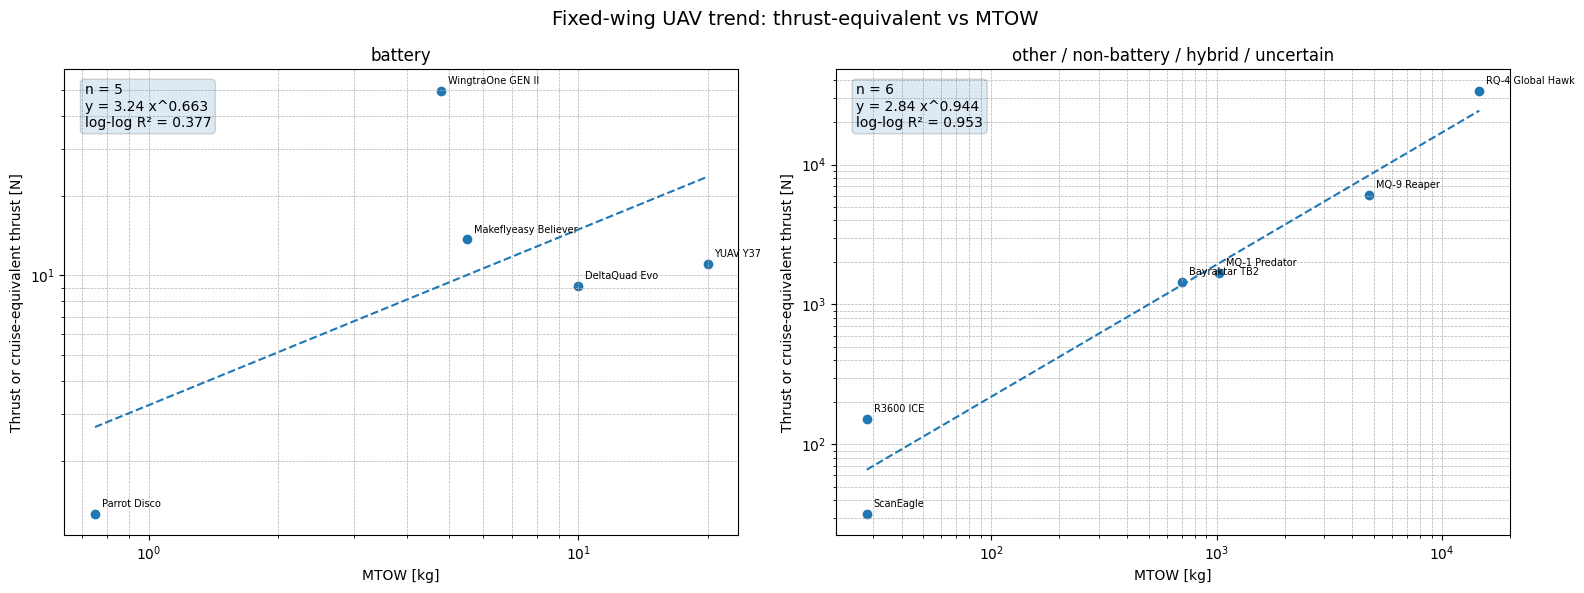

,plot_group,aircraft,power_source,mtow_kg,thrust_equiv_N,thrust_data_type,cruise_speed_ms,battery_Wh,endurance_h,source_url
0,battery,WingtraOne GEN II,battery,4.80,49.896000,"estimated from battery energy, endurance and c...",2.824859,198.00,0.983333,https://www.korecgroup.com/product/wingtraone-...
1,battery,DeltaQuad Evo,battery,10.00,9.119070,"estimated from battery energy, endurance and c...",16.540000,976.80,4.533333,https://www.deltaquad.com/resources/technical-...
2,battery,YUAV Y37,battery,20.00,11.040974,"estimated from battery energy, endurance and c...",20.138889,2700.00,8.500000,https://www.skyeyeuav.com/yuav-y37-a-new-stand...
3,battery,Makeflyeasy Believer,battery,5.50,13.675200,"estimated from battery energy, endurance and c...",20.000000,488.40,1.250000,https://en.makeflyeasy.com/index.php/believer/...
4,battery,Parrot Disco,battery,0.75,1.258740,"estimated from battery energy, endurance and c...",22.222222,29.97,0.750000,https://www.parrot.com
5,other / non-battery / hybrid / uncertain,RQ-4 Global Hawk,fossil fuel,14628.00,33806.472000,published thrust,159.477640,NaN,34.000000,https://www.af.mil/About-Us/Fact-Sheets/Displa...
6,other / non-battery / hybrid / uncertain,MQ-9 Reaper,fossil fuel,4760.00,6088.009579,estimated from published shaft/electric power ...,77.166600,NaN,27.000000,https://www.af.mil/About-Us/Fact-Sheets/Displa...
7,other / non-battery / hybrid / uncertain,MQ-1 Predator,fossil fuel,1020.00,1671.707708,estimated from published shaft/electric power ...,36.011080,NaN,24.000000,https://en.wikipedia.org/wiki/General_Atomics_...
8,other / non-battery / hybrid / uncertain,Bayraktar TB2,fossil fuel,700.00,1449.526090,estimated from published shaft/electric power ...,36.011080,NaN,27.000000,https://baykartech.com/en/uav/bayraktar-tb2/
9,other / non-battery / hybrid / uncertain,ScanEagle,fossil fuel,28.00,31.845228,estimated from published shaft/electric power ...,24.587200,NaN,20.000000,https://www.af.mil/About-Us/Fact-Sheets/Displa...


In [29]:
# ============================================================
# 1) Thrust-equivalent vs MTOW
# ============================================================
#
# This keeps electric aircraft where possible by estimating:
#
#   average electric power = battery_Wh / endurance_h
#   thrust_equiv = eta_prop * average_power / cruise_speed
#
# This is NOT static thrust. It is a cruise-equivalent propulsive force.

thrust_results = plot_split_trend(
    df,
    x_col="mtow_kg",
    y_col="thrust_equiv_N",
    title="Fixed-wing UAV trend: thrust-equivalent vs MTOW",
    x_label="MTOW [kg]",
    y_label="Thrust or cruise-equivalent thrust [N]",
)

show_plot_data(
    thrust_results,
    [
        "plot_group",
        "aircraft",
        "power_source",
        "mtow_kg",
        "thrust_equiv_N",
        "thrust_data_type",
        "cruise_speed_ms",
        "battery_Wh",
        "endurance_h",
        "source_url",
    ],
)

##### MTOW vs Wing loading

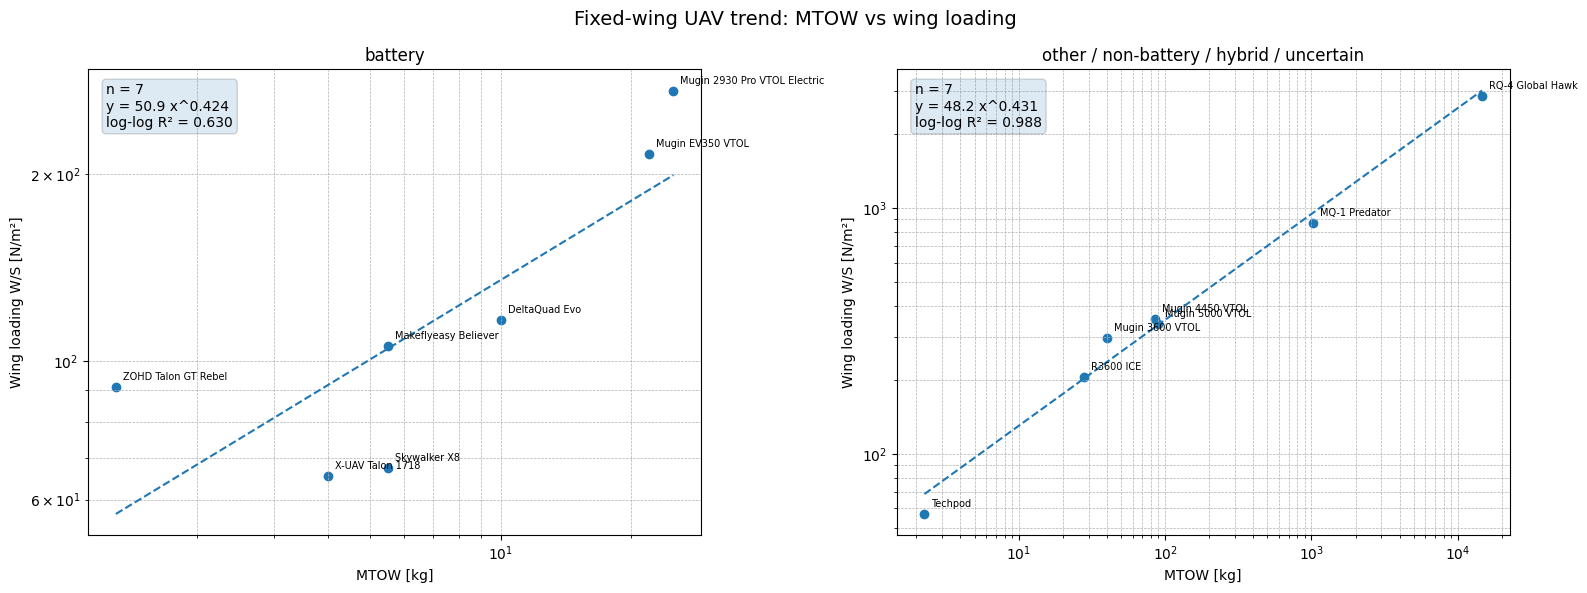

,plot_group,aircraft,power_source,mtow_kg,wingspan_m,wing_area_m2,wing_loading_N_m2,wing_loading_kg_m2,source_url
0,battery,DeltaQuad Evo,battery,10.000000,2.6900,0.840000,116.745833,11.904762,https://www.deltaquad.com/resources/technical-...
1,battery,Mugin EV350 VTOL,battery,22.000000,3.5000,1.000000,215.746300,22.000000,https://www.muginuav.com/wp-content/uploads/20...
2,battery,Mugin 2930 Pro VTOL Electric,battery,25.000000,2.9300,0.900000,272.406944,27.777778,https://seabee.no/mugin-2-pro-2930mm/
3,battery,Skywalker X8,battery,5.500000,2.1200,0.800000,67.420719,6.875000,https://www.uavmodel.com/products/skywalker-x8...
4,battery,Makeflyeasy Believer,battery,5.500000,1.9600,0.510000,105.757990,10.784314,https://en.makeflyeasy.com/index.php/believer/...
5,battery,X-UAV Talon 1718,battery,4.000000,1.7180,0.600000,65.377667,6.666667,https://www.3dxr.co.uk/products/x-uav-talon-fu...
6,battery,ZOHD Talon GT Rebel,battery,1.300000,1.0000,0.140000,91.061750,9.285714,https://cdn.robotshop.com/media/s/son/rb-son-2...
7,other / non-battery / hybrid / uncertain,RQ-4 Global Hawk,fossil fuel,14628.000000,39.8000,50.100000,2863.306910,291.976048,https://www.af.mil/About-Us/Fact-Sheets/Displa...
8,other / non-battery / hybrid / uncertain,MQ-1 Predator,fossil fuel,1020.000000,14.8000,11.450000,873.605502,89.082969,https://en.wikipedia.org/wiki/General_Atomics_...
9,other / non-battery / hybrid / uncertain,R3600 ICE,fossil fuel,28.000000,3.6000,1.330000,206.455789,21.052632,https://mbptech.de/en/drones/


In [30]:
# ============================================================
# 2) MTOW vs wing loading
# ============================================================
#
# Wing loading:
#
#   W/S = MTOW * g / wing_area

wing_loading_results = plot_split_trend(
    df,
    x_col="mtow_kg",
    y_col="wing_loading_N_m2",
    title="Fixed-wing UAV trend: MTOW vs wing loading",
    x_label="MTOW [kg]",
    y_label="Wing loading W/S [N/m²]",
)

show_plot_data(
    wing_loading_results,
    [
        "plot_group",
        "aircraft",
        "power_source",
        "mtow_kg",
        "wingspan_m",
        "wing_area_m2",
        "wing_loading_N_m2",
        "wing_loading_kg_m2",
        "source_url",
    ],
)

##### MTOW vs Range

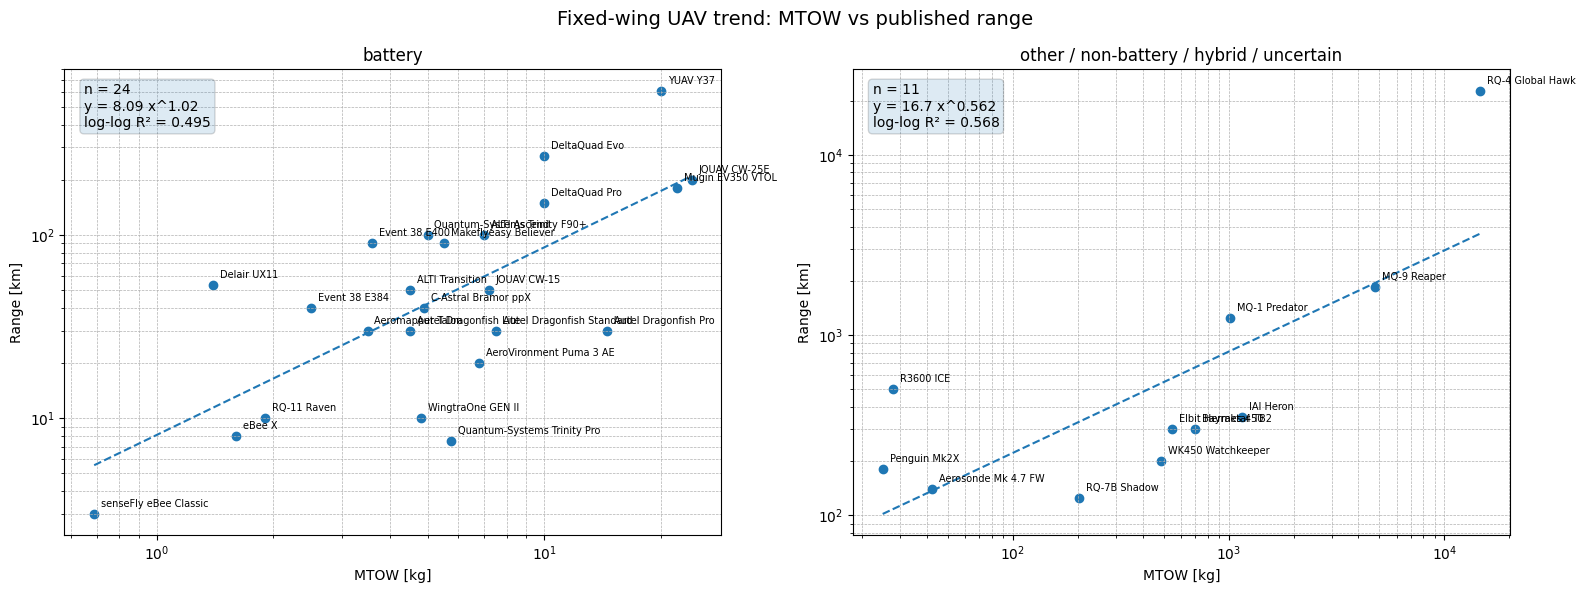

,plot_group,aircraft,power_source,mtow_kg,range_km,range_type,endurance_h,cruise_speed_ms,cruise_speed_source,source_url
0,battery,eBee X,battery,1.600000,8.0000,"radio link range, up to figure",1.500000,20.833333,published or manually entered from source,https://www.sensefly.com/drones/ebee-x/ ; http...
1,battery,senseFly eBee Classic,battery,0.690000,3.0000,radio link range,0.750000,1.111111,estimated from range/endurance,https://hkd-geomatique.com/images/04_Technolog...
2,battery,WingtraOne GEN II,battery,4.800000,10.0000,telemetry range,0.983333,2.824859,estimated from range/endurance,https://www.korecgroup.com/product/wingtraone-...
3,battery,Quantum-Systems Trinity F90+,battery,5.000000,100.0000,unlocked range figure; source also gives 70 km...,1.500000,17.000000,published or manually entered from source,https://bssholland.com/product/trinity-f90-evt...
4,battery,Quantum-Systems Trinity Pro,battery,5.750000,7.5000,"command and control range, upper figure",1.500000,17.000000,published or manually entered from source,https://quantum-systems.com/trinity-pro/
5,battery,DeltaQuad Evo,battery,10.000000,270.0000,range through air,4.533333,16.540000,published or manually entered from source,https://www.deltaquad.com/resources/technical-...
6,battery,DeltaQuad Pro,battery,10.000000,150.0000,auxiliary battery range figure,2.000000,20.833333,estimated from range/endurance,https://www.heliguy.com/blogs/posts/heliguy-se...
7,battery,AeroVironment Puma 3 AE,battery,6.803886,20.0000,standard range; other source variants give 15 ...,3.000000,1.851852,estimated from range/endurance,https://www.avinc.com/solution/puma-3-ae/ ; ht...
8,battery,RQ-11 Raven,battery,1.905088,10.0000,operational range,1.000000,2.777778,estimated from range/endurance,https://investor.avinc.com/news-releases/news-...
9,battery,YUAV Y37,battery,20.000000,614.0000,validated maximum range claimed by source,8.500000,20.138889,published or manually entered from source,https://www.skyeyeuav.com/yuav-y37-a-new-stand...


In [31]:
# ============================================================
# 3) MTOW vs range
# ============================================================
#
# Be careful:
# Some rows use aerodynamic range, some use operating range,
# some use communications/control range.
# The range_type column tells you which is which.

range_results = plot_split_trend(
    df,
    x_col="mtow_kg",
    y_col="range_km",
    title="Fixed-wing UAV trend: MTOW vs published range",
    x_label="MTOW [kg]",
    y_label="Range [km]",
)

show_plot_data(
    range_results,
    [
        "plot_group",
        "aircraft",
        "power_source",
        "mtow_kg",
        "range_km",
        "range_type",
        "endurance_h",
        "cruise_speed_ms",
        "cruise_speed_source",
        "source_url",
    ],
)

##### Wing Loading vs Aspect Ratio

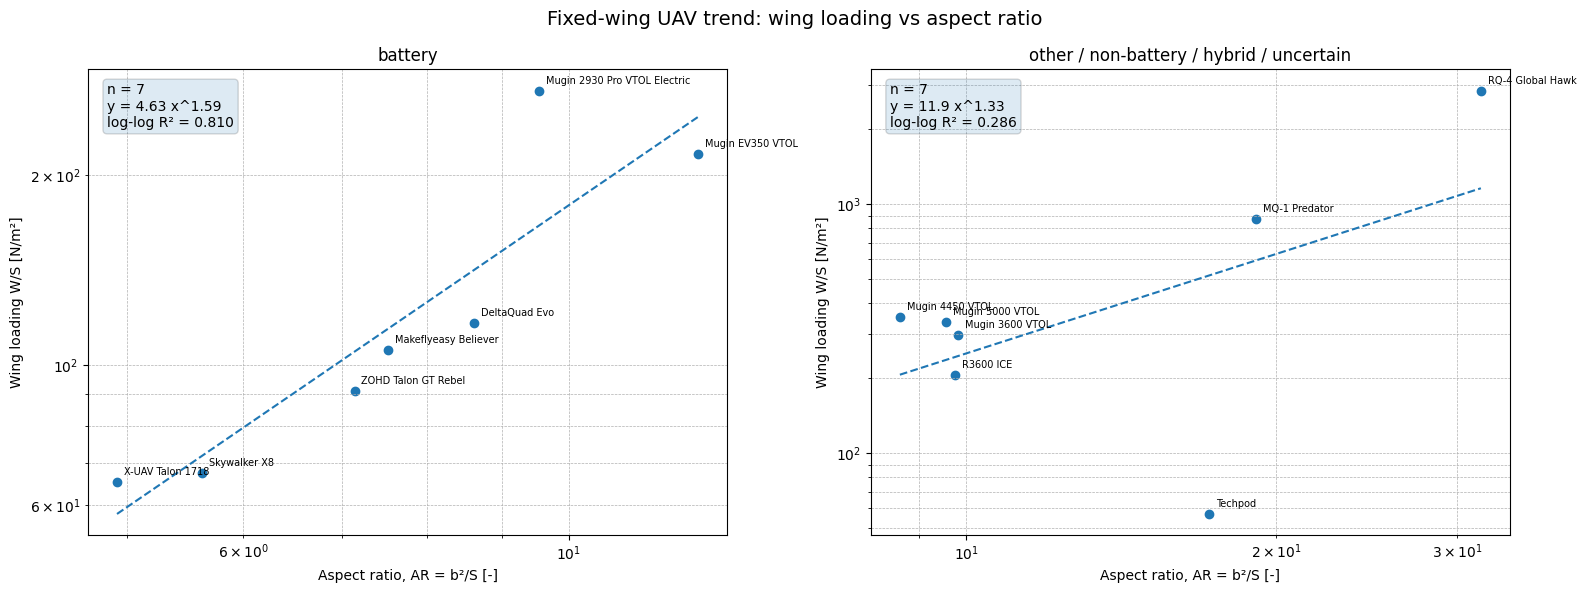

,plot_group,aircraft,power_source,wingspan_m,wing_area_m2,aspect_ratio,wing_loading_N_m2,wing_loading_kg_m2,source_url
0,battery,DeltaQuad Evo,battery,2.6900,0.840000,8.614405,116.745833,11.904762,https://www.deltaquad.com/resources/technical-...
1,battery,Mugin EV350 VTOL,battery,3.5000,1.000000,12.250000,215.746300,22.000000,https://www.muginuav.com/wp-content/uploads/20...
2,battery,Mugin 2930 Pro VTOL Electric,battery,2.9300,0.900000,9.538778,272.406944,27.777778,https://seabee.no/mugin-2-pro-2930mm/
3,battery,Skywalker X8,battery,2.1200,0.800000,5.618000,67.420719,6.875000,https://www.uavmodel.com/products/skywalker-x8...
4,battery,Makeflyeasy Believer,battery,1.9600,0.510000,7.532549,105.757990,10.784314,https://en.makeflyeasy.com/index.php/believer/...
5,battery,X-UAV Talon 1718,battery,1.7180,0.600000,4.919207,65.377667,6.666667,https://www.3dxr.co.uk/products/x-uav-talon-fu...
6,battery,ZOHD Talon GT Rebel,battery,1.0000,0.140000,7.142857,91.061750,9.285714,https://cdn.robotshop.com/media/s/son/rb-son-2...
7,other / non-battery / hybrid / uncertain,RQ-4 Global Hawk,fossil fuel,39.8000,50.100000,31.617565,2863.306910,291.976048,https://www.af.mil/About-Us/Fact-Sheets/Displa...
8,other / non-battery / hybrid / uncertain,MQ-1 Predator,fossil fuel,14.8000,11.450000,19.130131,873.605502,89.082969,https://en.wikipedia.org/wiki/General_Atomics_...
9,other / non-battery / hybrid / uncertain,R3600 ICE,fossil fuel,3.6000,1.330000,9.744361,206.455789,21.052632,https://mbptech.de/en/drones/


In [32]:
# ============================================================
# 4) Wing loading vs aspect ratio
# ============================================================
#
# Aspect ratio:
#
#   AR = b² / S

ar_results = plot_split_trend(
    df,
    x_col="aspect_ratio",
    y_col="wing_loading_N_m2",
    title="Fixed-wing UAV trend: wing loading vs aspect ratio",
    x_label="Aspect ratio, AR = b²/S [-]",
    y_label="Wing loading W/S [N/m²]",
)

show_plot_data(
    ar_results,
    [
        "plot_group",
        "aircraft",
        "power_source",
        "wingspan_m",
        "wing_area_m2",
        "aspect_ratio",
        "wing_loading_N_m2",
        "wing_loading_kg_m2",
        "source_url",
    ],
)

##### Endurance vs Battery Size

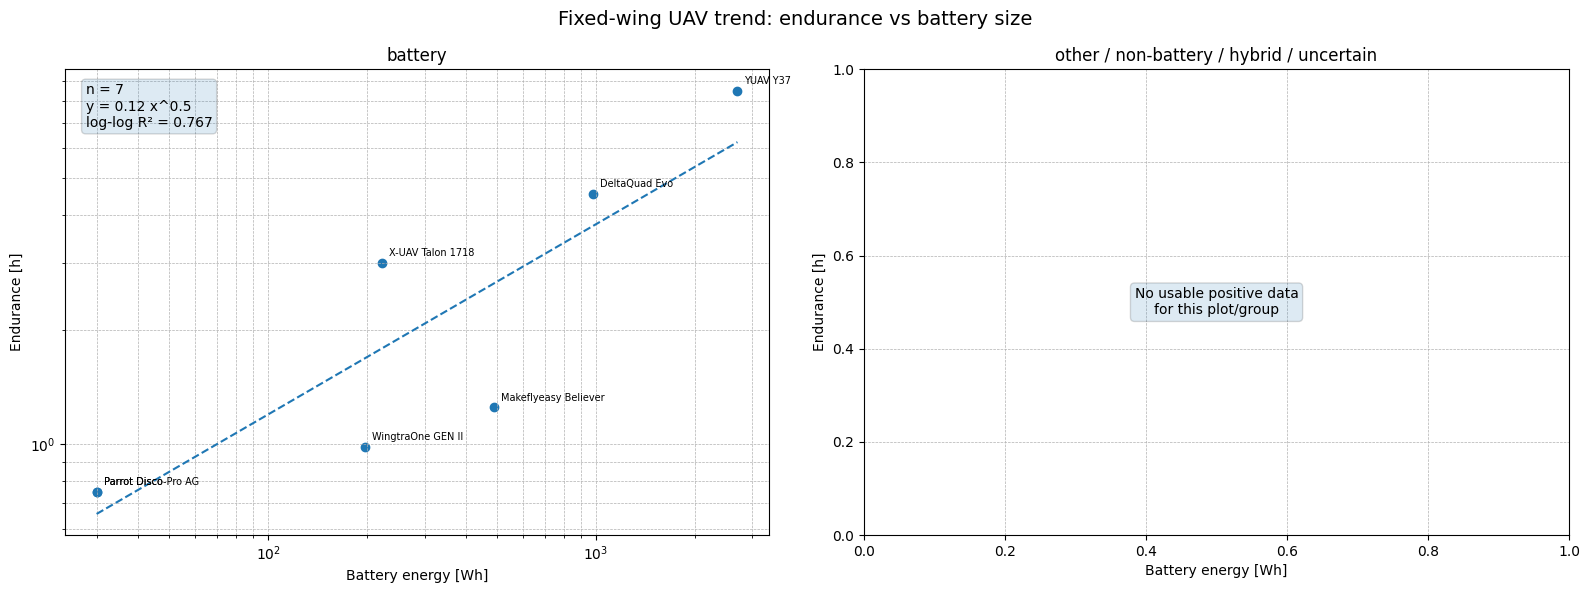

,plot_group,aircraft,power_source,mtow_kg,battery_Wh,battery_Ah,battery_voltage_V,battery_cells,battery_packs_parallel,battery_size_note,endurance_h,source_url
0,battery,WingtraOne GEN II,battery,4.80,198.00,7.5,14.4,NaN,1,two 99 Wh batteries required as a pair,0.983333,https://www.korecgroup.com/product/wingtraone-...
1,battery,DeltaQuad Evo,battery,10.00,976.80,22.0,NaN,6.0,2,dual-battery case; source gives 6 cells and 22...,4.533333,https://www.deltaquad.com/resources/technical-...
2,battery,YUAV Y37,battery,20.00,2700.00,NaN,48.0,NaN,1,"48 V, 2700 Wh battery",8.500000,https://www.skyeyeuav.com/yuav-y37-a-new-stand...
3,battery,Makeflyeasy Believer,battery,5.50,488.40,22.0,NaN,6.0,1,6S 22000 mAh mentioned in community/source lis...,1.250000,https://en.makeflyeasy.com/index.php/believer/...
4,battery,X-UAV Talon 1718,battery,4.00,222.00,15.0,NaN,4.0,1,4S 15000 mAh mentioned in source; Wh estimated,3.000000,https://www.3dxr.co.uk/products/x-uav-talon-fu...
5,battery,Parrot Disco,battery,0.75,29.97,2.7,NaN,3.0,1,typical 3S 2700 mAh pack; Wh estimated,0.750000,https://www.parrot.com
6,battery,Parrot Disco-Pro AG,battery,0.75,29.97,2.7,NaN,3.0,1,same airframe family as Parrot Disco; verify f...,0.750000,https://www.parrot.com


In [33]:
# ============================================================
# 5) Endurance vs battery size
# ============================================================
#
# This is mainly meaningful for battery-electric aircraft.
# The right-hand plot is still shown for completeness, but most
# non-battery aircraft will not have battery_Wh.

battery_endurance_results = plot_split_trend(
    df,
    x_col="battery_Wh",
    y_col="endurance_h",
    title="Fixed-wing UAV trend: endurance vs battery size",
    x_label="Battery energy [Wh]",
    y_label="Endurance [h]",
)

show_plot_data(
    battery_endurance_results,
    [
        "plot_group",
        "aircraft",
        "power_source",
        "mtow_kg",
        "battery_Wh",
        "battery_Ah",
        "battery_voltage_V",
        "battery_cells",
        "battery_packs_parallel",
        "battery_size_note",
        "endurance_h",
        "source_url",
    ],
)